In [1]:
import datetime

from tidepool_data_science_models.models.simple_metabolism_model import SimpleMetabolismModel

from tidepool_data_science_simulator.models.simulation import Simulation, TargetRangeSchedule24hr, SettingSchedule24Hr, BasalSchedule24hr
from tidepool_data_science_simulator.models.controller import DoNothingController, LoopController
from tidepool_data_science_simulator.models.patient import VirtualPatient
from tidepool_data_science_simulator.models.pump import ContinuousInsulinPump
from tidepool_data_science_simulator.models.sensor import IdealSensor
from tidepool_data_science_simulator.models.measures import InsulinSensitivityFactor, BasalRate

from tidepool_data_science_simulator.makedata.make_simulation import get_canonical_simulation
from tidepool_data_science_simulator.makedata.make_controller import get_canonical_controller_config
from tidepool_data_science_simulator.makedata.make_patient import (
  DATETIME_DEFAULT, get_canonical_risk_patient_config, get_canonical_risk_pump_config,
    get_canonical_sensor_config
)

from tidepool_data_science_simulator.models.events import BolusTimeline, CarbTimeline
from tidepool_data_science_simulator.models.measures import Bolus, Carb, TargetRange

from tidepool_data_science_simulator.visualization.sim_viz import plot_sim_results

numexpr.utils: INFO     Note: NumExpr detected 14 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
numexpr.utils: INFO     NumExpr defaulting to 8 threads.


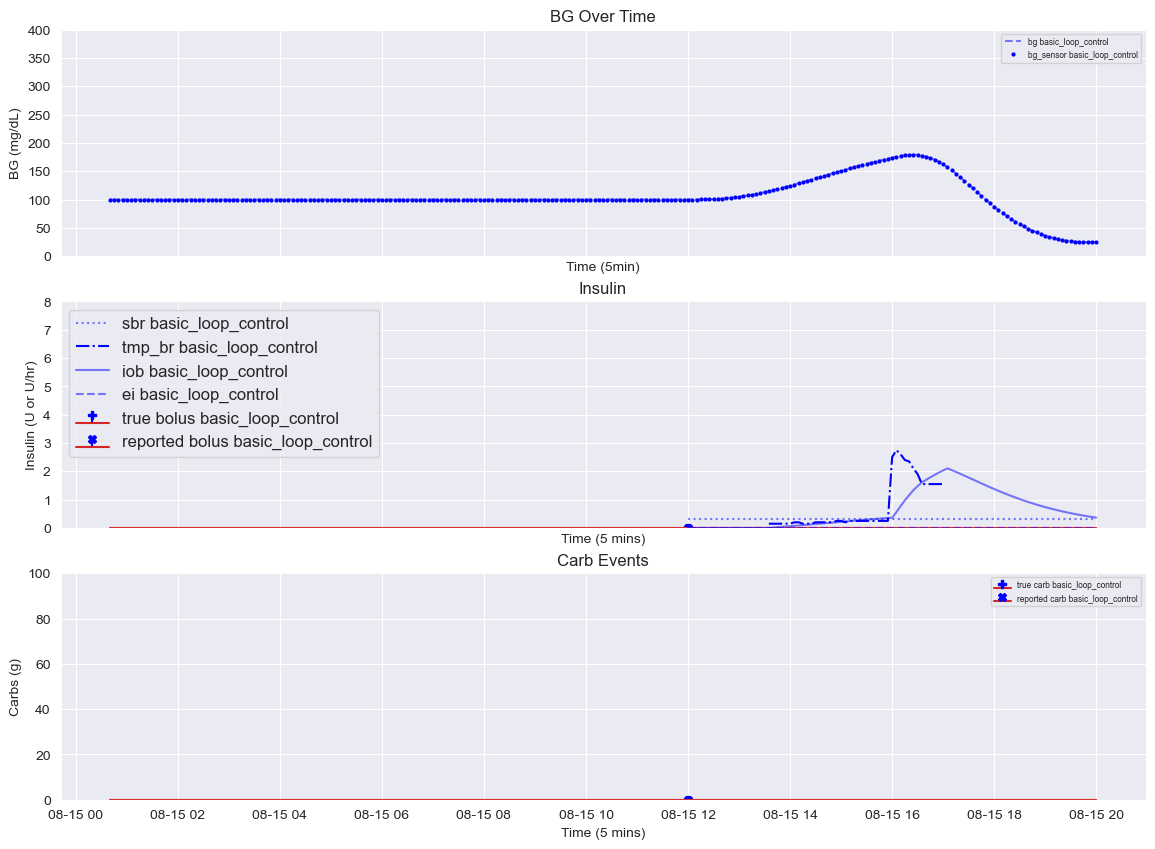

In [4]:
isf_settings = [150, 15]
isf_times = [datetime.time(0, 0, 0), datetime.time(16, 0, 0)]
isf_durations = [16*60, 8*60]

t0, patient_config = get_canonical_risk_patient_config(start_glucose_value=100)
t0, sensor_config = get_canonical_sensor_config(start_value=100)
t0, controller_config = get_canonical_controller_config()
t0, pump_config = get_canonical_risk_pump_config()

bolus_timeline = BolusTimeline(datetimes=[t0], events=[Bolus(0, "U")])
patient_config.bolus_event_timeline = bolus_timeline
pump_config.bolus_event_timeline = bolus_timeline

true_carb_timeline = CarbTimeline(datetimes=[t0], events=[Carb(0, "U", 180)])
# true_carb_timeline = []
patient_config.carb_event_timeline = true_carb_timeline
pump_config.carb_event_timeline = true_carb_timeline

new_sensitivity_schedule = \
    SettingSchedule24Hr(
        t0,
        name='ISF',
        start_times=isf_times,
        values=[InsulinSensitivityFactor(isf, "mg/dL / U") for isf in isf_settings],
        duration_minutes=isf_durations
    )

pump_config.insulin_sensitivity_schedule = new_sensitivity_schedule

new_basal_schedule = \
    BasalSchedule24hr(
        t0,
        start_times=[datetime.time(0,0,0)],
        values = [BasalRate(0, "mg/dL")],
        duration_minutes=[1440]
    )
pump_config.basal_schedule = new_basal_schedule

pump = ContinuousInsulinPump(pump_config, t0)
sensor = IdealSensor(t0, sensor_config)

controller = LoopController(t0, controller_config)

vp = VirtualPatient(
    time=DATETIME_DEFAULT,
    pump=pump,
    sensor=sensor,
    metabolism_model=SimpleMetabolismModel,
    patient_config=patient_config
)

sim_id = "basic_loop_control"
sim = Simulation(
    time=t0,
    duration_hrs=8,
    virtual_patient=vp,
    controller=controller,
    sim_id=sim_id
)

sim.run()
sim_results_df = sim.get_results_df()

plot_sim_results({sim_id: sim_results_df})